# 3. Feature Engineering (Ingeniería de Características)

**Punto de partida:** el dataset crudo (`../data/WA_Fn-UseC_-Telco-Customer-Churn.csv`), el mismo archivo usado en `2_EDA.ipynb`. Este notebook se ejecuta de forma independiente y vuelve a cargar los datos desde cero (no depende de variables en memoria de otros notebooks), de manera que pueda ejecutarse por separado como módulo de clase.

La ingeniería de características es la etapa del proceso analítico en la que transformamos, combinamos o construimos variables con el objetivo de representar mejor el fenómeno de negocio y preparar los datos para el modelamiento analítico.

Los datos dejan de ser únicamente registros operativos y se convierten en variables analíticas informativas, interpretables y reproducibles.

**Entrega de este notebook:** `../data/preprocessed_data.csv`, el archivo que consume directamente `4_Modeling.ipynb`.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## cargar librerias de visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

## Cargar datos

Se lee nuevamente el dataset crudo. A diferencia de `2_EDA.ipynb`, aquí sí se especifican explícitamente `sep` y `na_values`, ya que las decisiones de limpieza tomadas en el EDA (por ejemplo, qué se considera un valor faltante) se aplican de forma explícita desde la carga.

In [2]:
## Cargar datos
fName = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

raw = pd.read_csv(
                    fName
                    , sep=",", na_values=[""," ","-","NA"]
                )
print("Dimensiones del dataset original:", raw.shape)

Dimensiones del dataset original: (7043, 21)


Se crea una copia del `DataFrame` original (`raw`) sobre la cual se trabajará (`df`), se define el `target` y se establece `customerID` como índice — la misma decisión validada en el EDA.

In [3]:
df = raw.copy()
target = "Churn"
df.set_index("customerID", inplace=True)
print("Dimensiones de `df`:", df.shape)
df.head()

Dimensiones de `df`: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Distribución del target

Se revisa nuevamente el balance de clases de `Churn`. Este dato es clave más adelante, en `4_Modeling.ipynb`, para decidir usar partición estratificada y priorizar métricas como Recall o F1 sobre Accuracy.

In [4]:
pd.concat([df[target].value_counts(), (df[target].value_counts(normalize=True)*100).round(2)], axis=1)

,count,proportion
Churn,,
No,5174,73.46
Yes,1869,26.54


## Preparación del dataset para implementación de ML

A partir de aquí se implementan las revisiones y técnicas de preparación necesarias para dejar el dataset listo para modelado, teniendo en cuenta cada característica, su distribución y su tipo de dato. Las decisiones que siguen retoman directamente los hallazgos del EDA (`2_EDA.ipynb`).

### Validación de nulos

In [5]:
## Verificar valores nulos
df.isnull().sum()[df.isnull().sum()>0]

TotalCharges    11
dtype: int64

In [6]:
nulos = df[df.isnull().sum(axis=1)>0]
print("Registros que tiene al menos un valor NULO =", len(nulos))
nulos

Registros que tiene al menos un valor NULO = 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No


In [7]:
print("Distribución de la variable objetivo en los registros con al menos un valor NULO")
pd.concat([nulos[target].value_counts(), nulos[target].value_counts(normalize=True)], axis=1)

Distribución de la variable objetivo en los registros con al menos un valor NULO


,count,proportion
Churn,,
No,11,1.0


### ¿Qué hacer con los valores nulos?

Las técnicas o procesos más comunes para tratarlos son:
* Eliminación de los registros.
* Imputación por promedio/mediana.
* Evaluación del contexto de negocio (¿por qué está nulo este dato específicamente?).

In [8]:
# Descripción estadística de la variable `TotalCharges`
df[["TotalCharges"]].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalCharges,7032.0,2283.300441,2266.771362,18.8,401.45,1397.475,3794.7375,8684.8


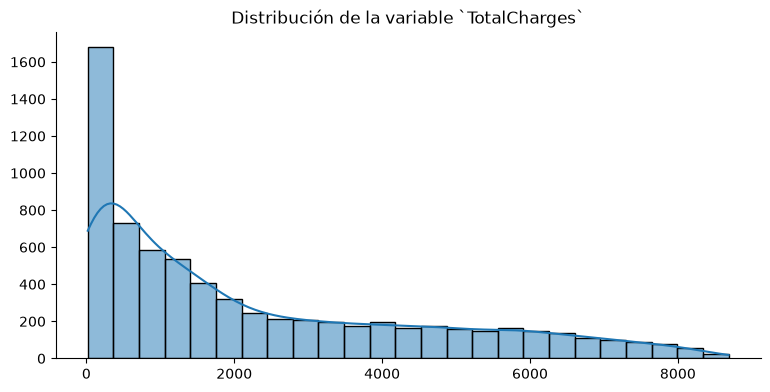

In [9]:
sns.displot(df["TotalCharges"], kde=True, height=4, aspect=2)
plt.title("Distribución de la variable `TotalCharges`")
plt.xlabel(None)
plt.ylabel(None)
plt.show()

In [10]:
nulos.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,11.0,0.000000,0.000000,0.0,0.000,0.00,0.000,0.00
tenure,11.0,0.000000,0.000000,0.0,0.000,0.00,0.000,0.00
MonthlyCharges,11.0,41.418182,23.831484,19.7,20.125,25.75,58.975,80.85
TotalCharges,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


De acuerdo con la distribución estadística de la característica y las técnicas disponibles para manejar nulos, se pueden implementar cualquiera de estas estrategias:

1. Descartar los registros, ya que corresponden solo a 11 (0.15%) registros del total.
2. Imputar por el promedio, que corresponde a `2283.3` — *en este contexto, y de acuerdo con la    distribución, no es lo más acertado*.
3. Dado que la variable `tenure` es `0` para todos estos casos, se trata de clientes completamente    nuevos que aún no han generado un cargo total (`TotalCharges`). Por lo tanto, se podría:
    * imputar con `0`, ya que son nuevos, o
    * imputar con el valor de `MonthlyCharges` para cada registro, asumiendo que ese será el primer       cargo que se les facture.

In [11]:
pd.concat([
            df[["TotalCharges"]].describe().T
            , df[["TotalCharges"]].fillna(0).describe().T
            , df[["TotalCharges"]].fillna(df["MonthlyCharges"]).describe().T
        ])

,count,mean,std,min,25%,50%,75%,max
TotalCharges,7032.0,2283.300441,2266.771362,18.8,401.45,1397.475,3794.7375,8684.8
TotalCharges,7043.0,2279.734304,2266.794470,0.0,398.55,1394.550,3786.6000,8684.8
TotalCharges,7032.0,2283.300441,2266.771362,18.8,401.45,1397.475,3794.7375,8684.8


**Decisión adoptada:** se reemplazan los valores nulos de `TotalCharges` por el valor de `MonthlyCharges`. Esto se debe a que los registros con valores nulos en `TotalCharges` corresponden exactamente a clientes con `tenure = 0` (clientes nuevos, sin cargos acumulados aún). Por lo tanto, usar el cargo mensual como estimación del cargo total es la opción más consistente con el contexto de negocio, sin sesgar la distribución de la variable con un valor arbitrario como el promedio.

In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

In [13]:
print("items con valores nulos =", df.isnull().sum().sum())


items con valores nulos = 0


## Técnicas para transformación de variables

### Numéricas
* **Escalamiento Min-Max**: útil cuando se requiere un rango común entre variables.
* **Estandarización (Z-score)**: útil para modelos sensibles a la escala (ej. Regresión Logística).
* **Transformación logarítmica**: útil cuando existen distribuciones altamente asimétricas.
* **Discretización (binning)**: convierte una variable continua en categorías interpretables.

Se identifican las variables numéricas del dataset.

In [14]:
cols_num = list(df.select_dtypes(["int","float"]).columns)
df[cols_num].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.798992,2266.730170,18.80,398.55,1394.55,3786.60,8684.80


Se evidencia dispersión entre las magnitudes de las variables numéricas, por lo que se recomienda normalizar o estandarizar los datos antes de aplicar cualquier modelo de machine learning.

**Nota importante:** el escalamiento en sí **no se ejecuta en este notebook**. Se deja documentado aquí como parte del diagnóstico, pero se aplica más adelante en `4_Modeling.ipynb`, y únicamente sobre el conjunto de `train` (para evitar fuga de información hacia el conjunto de `test`).

### Categóricas

* **Binarias**: True/False, Sí/No → 1 y 0.
* **One-Hot Encoding**: convertir cada categoría de la variable en una nueva columna con valores 1 y 0.
* **Label Encoding**: convierte cada categoría en un único valor numérico (útil para variables ordinales).

Se empieza por las variables dicotómicas, convertidas directamente a 1|0, por ejemplo: `No=0` y `Yes=1`.

In [15]:
cols_to_bool = ["Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
df[cols_to_bool] = df[cols_to_bool].apply(lambda x: x.map({"No":0, "Yes":1}))
df[cols_to_bool].describe().T

,count,mean,std,min,25%,50%,75%,max
Partner,7043.0,0.483033,0.499748,0.0,0.0,0.0,1.0,1.0
Dependents,7043.0,0.299588,0.458110,0.0,0.0,0.0,1.0,1.0
PhoneService,7043.0,0.903166,0.295752,0.0,1.0,1.0,1.0,1.0
PaperlessBilling,7043.0,0.592219,0.491457,0.0,0.0,1.0,1.0,1.0
Churn,7043.0,0.265370,0.441561,0.0,0.0,0.0,1.0,1.0


`gender` es una variable categórica, pero al tener solo 2 valores posibles se puede tratar de forma binaria igual que las anteriores.

In [16]:
df["gender"] = df["gender"].map({"Male":0, "Female":1})
pd.concat([df["gender"].value_counts(), df["gender"].value_counts(normalize=True)], axis=1)

,count,proportion
gender,,
0,3555,0.504756
1,3488,0.495244


Se revisan las variables categóricas que tienen 3 opciones posibles (por ejemplo `Yes`, `No`, `No internet service`).

In [17]:
print("Distribución de las varibales (en %):")
cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for c in cols:
    print(c, (df[c].value_counts(normalize=True)*100).round(1).to_dict())

Distribución de las varibales (en %):
MultipleLines {'No': 48.1, 'Yes': 42.2, 'No phone service': 9.7}
OnlineSecurity {'No': 49.7, 'Yes': 28.7, 'No internet service': 21.7}
OnlineBackup {'No': 43.8, 'Yes': 34.5, 'No internet service': 21.7}
DeviceProtection {'No': 43.9, 'Yes': 34.4, 'No internet service': 21.7}
TechSupport {'No': 49.3, 'Yes': 29.0, 'No internet service': 21.7}
StreamingTV {'No': 39.9, 'Yes': 38.4, 'No internet service': 21.7}
StreamingMovies {'No': 39.5, 'Yes': 38.8, 'No internet service': 21.7}


Para efectos de modelado, la categoría `No internet service` se trata como equivalente a `No`, ya que en la práctica ambas significan "el cliente no tiene ese servicio activo". Por lo tanto, estas variables se tratan como dicotómicas: `Yes=1` y cualquier otro valor (`No` o `No internet service`) = `0`.

In [18]:
cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for c in cols:
    filtro = df[c]=="Yes"
    df[c] = filtro.astype(int)

Se listan las variables categóricas que aún quedan pendientes por codificar — aquellas con más de 2 o 3 categorías sin un tratamiento binario claro, como `InternetService`, `Contract` o `PaymentMethod`.

In [19]:
print("Variables pendientes por procesar (en %):")
cols_cat = list(df.select_dtypes(["object","str"]).columns)
for c in cols_cat:
    print(c, (df[c].value_counts(normalize=True)*100).round(1).to_dict())

Variables pendientes por procesar (en %):
InternetService {'Fiber optic': 44.0, 'DSL': 34.4, 'No': 21.7}
Contract {'Month-to-month': 55.0, 'Two year': 24.1, 'One year': 20.9}
PaymentMethod {'Electronic check': 33.6, 'Mailed check': 22.9, 'Bank transfer (automatic)': 21.9, 'Credit card (automatic)': 21.6}


### Conversión de variables a Dummies (One-Hot Encoding)

Para las variables categóricas restantes se aplica One-Hot Encoding: cada categoría se convierte en una columna binaria independiente. El `target` se conserva aparte y se reincorpora al final para no incluirlo por error en el proceso de codificación.

In [26]:
pd.get_dummies(df["InternetService"]).astype(int)
pd.get_dummies(df[cols_cat]).astype(int).shape
# cols_cat

(7043, 10)

In [27]:
df = pd.concat([
                df.drop(cols_cat + [target], axis=1),
                pd.get_dummies(df[cols_cat]).astype(int),
                df[target]
            ], axis=1
        )

In [28]:
pd.concat([df.describe().T, pd.DataFrame(df.sum(), columns=["sum"])], axis=1)

,count,mean,std,min,25%,50%,75%,max,sum
gender,7043.0,0.495244,0.500013,0.00,0.00,0.00,1.00,1.00,3488.0
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00,1142.0
Partner,7043.0,0.483033,0.499748,0.00,0.00,0.00,1.00,1.00,3402.0
Dependents,7043.0,0.299588,0.458110,0.00,0.00,0.00,1.00,1.00,2110.0
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,227990.0
PhoneService,7043.0,0.903166,0.295752,0.00,1.00,1.00,1.00,1.00,6361.0
MultipleLines,7043.0,0.421837,0.493888,0.00,0.00,0.00,1.00,1.00,2971.0
OnlineSecurity,7043.0,0.286668,0.452237,0.00,0.00,0.00,1.00,1.00,2019.0
OnlineBackup,7043.0,0.344881,0.475363,0.00,0.00,0.00,1.00,1.00,2429.0
DeviceProtection,7043.0,0.343888,0.475038,0.00,0.00,0.00,1.00,1.00,2422.0


# Análisis de correlación de variables

Con todas las variables ya en formato numérico (tras la codificación), se calcula la matriz de correlación completa para detectar redundancia entre variables antes de pasar al modelado.

In [29]:
df_corr = df.corr()

La librería `seaborn` permite visualizar mejor la matriz de correlación que la tabla numérica cruda.

In [30]:
## cargar librerias de visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

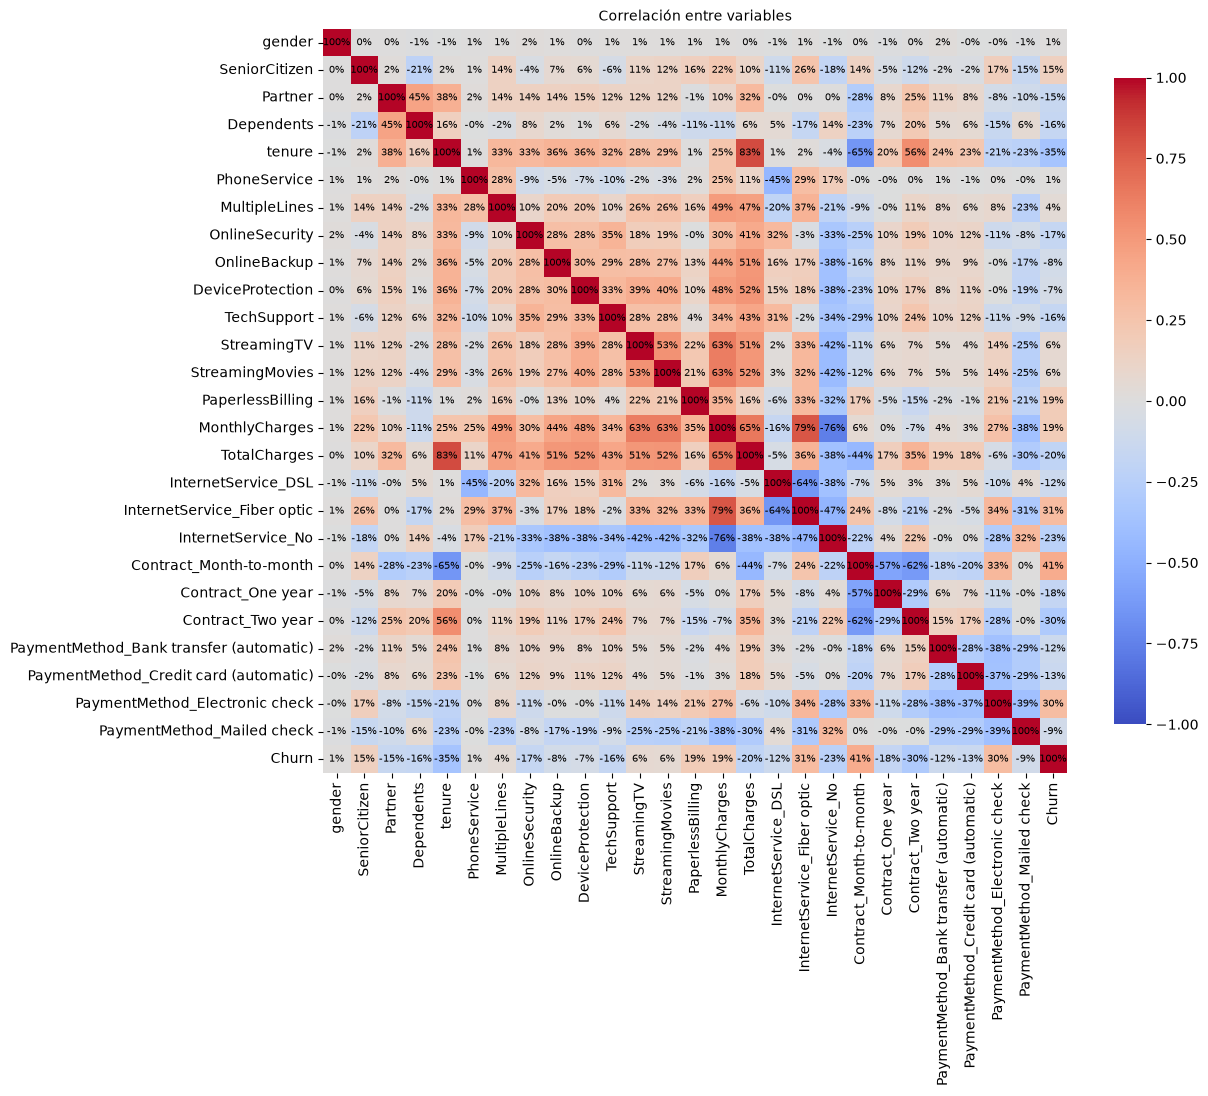

In [31]:
plt.figure(figsize=(12, 12))
sns.heatmap(
            df_corr
            , square=True
            , cmap="coolwarm"
            , annot=True, fmt=".0%"
            , annot_kws={"size": 7, 
                        #  "weight": "bold", 
                         "color": "black"}
            , cbar_kws={"shrink": 0.7}
            , vmin=-1, vmax=1
        )
plt.title("Correlación entre variables", fontsize=10
          )
plt.show()

Se ordenan las variables según su correlación directa con la variable objetivo (`Churn`), como primer filtro de relevancia.

In [32]:
print(f"Variables más correlacionadas con el {target=}:")
df_corr.loc[target].sort_values(ascending=False)[1:]

Variables más correlacionadas con el target='Churn':


Contract_Month-to-month                    0.405103
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
MonthlyCharges                             0.193356
PaperlessBilling                           0.191825
SeniorCitizen                              0.150889
StreamingTV                                0.063228
StreamingMovies                            0.061382
MultipleLines                              0.040102
PhoneService                               0.011942
gender                                     0.008612
DeviceProtection                          -0.066160
OnlineBackup                              -0.082255
PaymentMethod_Mailed check                -0.091683
PaymentMethod_Bank transfer (automatic)   -0.117937
InternetService_DSL                       -0.124214
PaymentMethod_Credit card (automatic)     -0.134302
Partner                                   -0.150448
Dependents                                -0.164221
TechSupport 

Dado que la variable `TotalCharges` presenta una alta correlación con `tenure` y una correlación moderada con `MonthlyCharges`, además de haber requerido imputación por valores faltantes, se decide evaluar su eliminación para reducir posible redundancia y simplificar el conjunto de variables.

In [33]:
df.drop("TotalCharges", axis=1, inplace=True, errors="ignore")

### Otras correlaciones

Más allá de la relación con el target, se revisan las correlaciones fuertes (|r| > 0.5) entre pares de variables predictoras, para identificar redundancia estructural (por ejemplo, generada por el propio One-Hot Encoding) frente a relaciones que sí aportan información de negocio.

In [34]:
df_corr_otros = df_corr[
                            (df_corr.abs()!=1) 
                            & ((df_corr>0.5) | (df_corr<-0.5))
                    ].unstack().dropna().reset_index().rename(columns={0:"correlacion"})

df_corr_otros["relacion"] = df_corr_otros.iloc[:,:2].apply(lambda x: " <-> ".join(sorted(list(x))), axis=1)
df_corr_otros[["relacion", "correlacion"]].sort_values("correlacion", ascending=False).drop_duplicates().set_index("relacion")

,correlacion
relacion,
TotalCharges <-> tenure,0.826164
InternetService_Fiber optic <-> MonthlyCharges,0.787066
MonthlyCharges <-> TotalCharges,0.651182
MonthlyCharges <-> StreamingTV,0.629603
MonthlyCharges <-> StreamingMovies,0.627429
Contract_Two year <-> tenure,0.558533
StreamingMovies <-> StreamingTV,0.533094
DeviceProtection <-> TotalCharges,0.522012
StreamingMovies <-> TotalCharges,0.520124


Se evidencian algunas relaciones que no aportan explicación adicional en una revisión inicial, por ejemplo:

* `InternetService_No` ↔ `MonthlyCharges` (-0.763): relación negativa fuerte y esperada por la lógica del negocio. Los clientes sin servicio de internet tienden a presentar cargos mensuales considerablemente menores. Esta correlación surge principalmente de la codificación One-Hot de una categoría mutuamente excluyente y no aporta información adicional relevante sobre el comportamiento del cliente.
* `InternetService_DSL` ↔ `InternetService_Fiber optic` (-0.641): correlación negativa esperada, ya que ambas variables representan categorías mutuamente excluyentes de la variable original `InternetService`. Esta relación es consecuencia directa del proceso de One-Hot Encoding y no debe interpretarse como una relación estadística entre servicios, sino como una dependencia estructural de la codificación.
* `StreamingMovies` y `StreamingTV` presentan una correlación positiva moderada entre sí (r ≈ 0.53), lo que sugiere que ambos servicios suelen contratarse de manera conjunta.
* Tanto `StreamingMovies` como `StreamingTV` muestran correlaciones positivas moderadas con `MonthlyCharges` (r ≈ 0.63), indicando que los servicios de entretenimiento contribuyen al incremento del valor mensual facturado al cliente. Estas relaciones sí aportan información útil sobre el comportamiento y el valor comercial del cliente, por lo que las variables se conservan en el conjunto de características.

**Nota metodológica:** dentro del proceso de One-Hot Encoding también se puede usar `drop_first=True` para eliminar automáticamente una categoría de referencia por variable y reducir la multicolinealidad estructural descrita arriba.

Con base en el hallazgo anterior, se elimina `InternetService_No` por ser una columna redundante: su información ya queda representada por la ausencia de `1` en `InternetService_DSL` e `InternetService_Fiber optic` (categorías mutuamente excluyentes generadas por el mismo One-Hot Encoding). Conservarla no aporta información nueva y sí incrementa la colinealidad estructural del conjunto de variables.

In [35]:
## eliminar catergoría "No internet service" de las variables categóricas relacionadas con el servicio de internet
df.drop("InternetService_No", axis=1, inplace=True)

# Resultados esperados

* Convertir variables al tipo de dato adecuado.
* Transformar variables numéricas para mejorar su representación.
* Codificar variables categóricas correctamente.
* Construir un conjunto de variables con sentido de negocio.
* Reducir redundancia entre variables.

Se estandarizan los nombres de columnas a minúsculas, por convención de estilo, antes de exportar el resultado final.

In [36]:
df.columns = df.columns.str.lower()
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,churn
customerID,,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,1,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,1,0,1,0,0,0,0,1,0,0
5575-GNVDE,0,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1,0,0,1,0,0,0,0,1,0
3668-QPYBK,0,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,1,0,1,0,0,0,0,0,1,1
7795-CFOCW,0,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1,0,0,1,0,1,0,0,0,0
9237-HQITU,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,0,1,1,0,0,0,0,1,0,1


### Entrega final

Se exporta el dataset ya limpio, transformado y codificado a `../data/preprocessed_data.csv`. Este es el archivo que consume directamente `4_Modeling.ipynb` para entrenar y comparar los modelos de clasificación.

In [37]:
df.to_csv("../data/preprocessed_data.csv")